## 1. Introduction
In this project, a **sequential ensemble learning** approach was applied to predict credit approval decisions using a structured financial dataset. The dataset used for this analysis is the **Credit Approval** dataset, which was obtained from OpenML through the **scikit-learn** library. It contains customer-related information such as credit history, loan amount, employment status, savings, and checking account details that help determine whether a loan application should be classified as **good or bad**.

The main objective of this project is to understand how sequential ensemble methods improve prediction performance compared to traditional machine learning models. A baseline model using **Logistic Regression** was implemented to establish initial performance. After that, the **AdaBoost classifier**, a sequential ensemble learning method, was applied to improve prediction accuracy by focusing on previously misclassified samples.

Model performance was evaluated using **accuracy**, **precision**, **recall**, **confusion matrix**, and learning curve analysis. **Hyperparameter tuning** was also performed to optimize the ensemble model. In addition, feature importance analysis was carried out to identify the most influential factors affecting credit approval decisions.

Overall, this project demonstrates how sequential ensemble techniques can support better decision-making in financial risk assessment and credit approval prediction tasks.

### 2.  Import Libraries

In [81]:
# Data handling
import pandas as pd
import numpy as np

# Dataset loader from sklearn
from sklearn.datasets import fetch_openml

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### 3.1 Dataset Description
The dataset used in this project is the **Credit Approval** dataset, which was obtained from OpenML using the **scikit-learn** library. It contains information about **1000** loan applicants along with **20** input features related to customers financial background, such as checking_status, duration, credit_history, purpose, credit_amount, savings_status, employment, installment_commitment, personal_status, other_parties, residence_since , property_magnitude, age, other_payment_plans, housing, existing_credits, job, num_dependents, own_telephone, foreign_worker. The target variable in the dataset indicates whether the applicant is classified as a **good or bad** credit risk.

Most of the features in the dataset are categorical, so they were converted into numerical form using encoding techniques before training the models. This dataset is commonly used for studying credit risk prediction and helps in understanding how machine learning models can support decision-making in loan approval processes.

### 3.2 Load Dataset

In [82]:
credit_data = fetch_openml(name='credit-g', as_frame=True)

df = credit_data.frame

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [83]:
df.columns

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

In [85]:
df.shape

(1000, 21)

In [86]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


### 4. Check null value

In [87]:
# Check missing values
df.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

In [88]:
df['class'].value_counts()

class
good    700
bad     300
Name: count, dtype: int64

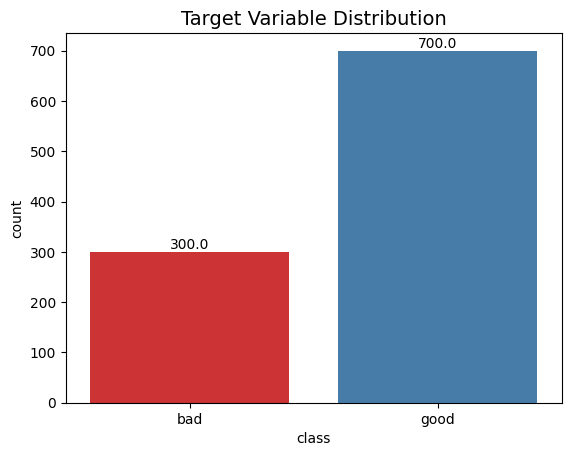

In [89]:
ax = sns.countplot(x='class', data=df,
                   palette='Set1')

plt.title("Target Variable Distribution", fontsize=14)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()

The dataset contains 1000 observations and 21 columns including the target variable. Most features are categorical in nature and require encoding before model training. The dataset does not contain missing values. The target variable shows a moderate class imbalance between approved (good) and rejected (bad) credit applications.

In [90]:
df['personal_status'].head(10)

0           male single
1    female div/dep/mar
2           male single
3           male single
4           male single
5           male single
6           male single
7           male single
8          male div/sep
9          male mar/wid
Name: personal_status, dtype: category
Categories (4, object): ['female div/dep/mar', 'male div/sep', 'male mar/wid', 'male single']

In [91]:
df['personal_status'].value_counts()

personal_status
male single           548
female div/dep/mar    310
male mar/wid           92
male div/sep           50
Name: count, dtype: int64

In [92]:
# Create gender column
df['gender'] = df['personal_status'].apply(
    lambda x: 'female' if 'female' in x else 'male'
)

# Create marital_status column
def extract_marital_status(x):
    if 'single' in x:
        return 'single'
    elif 'mar' in x or 'wid' in x:
        return 'married/widowed'
    elif 'div' in x or 'sep' in x:
        return 'divorced/separated'
    else:
        return 'unknown'

df['marital_status'] = df['personal_status'].apply(extract_marital_status)

# Drop original combined column
df.drop('personal_status', axis=1, inplace=True)

# Check result
df[['gender', 'marital_status']].head()

,gender,marital_status
0,male,single
1,female,married/widowed
2,male,single
3,male,single
4,male,single


### 5.  Separate Features (X) and Target (y)

In [93]:
X = df.drop('class', axis=1)
y = df['class']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1000, 21)
Shape of y: (1000,)


### 6. Encode Target Variable

In [94]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print("Encoded target values:", set(y))

Encoded target values: {np.int64(0), np.int64(1)}


### 7. Encode Categorical Features

In [95]:
# Encode categorical features using One-Hot Encoding

X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X_encoded.shape)

Shape after encoding: (1000, 48)


In [96]:
X_encoded.head()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_<0,checking_status_>=200,checking_status_no checking,...,housing_own,housing_rent,job_unemp/unskilled non res,job_unskilled resident,job_skilled,own_telephone_yes,foreign_worker_yes,gender_male,marital_status_married/widowed,marital_status_single
0,6,1169,4,4,67,2,1,True,False,False,...,True,False,False,False,True,True,True,True,False,True
1,48,5951,2,2,22,1,1,False,False,False,...,True,False,False,False,True,False,True,False,True,False
2,12,2096,2,3,49,1,2,False,False,True,...,True,False,False,True,False,False,True,True,False,True
3,42,7882,2,4,45,1,2,True,False,False,...,False,False,False,False,True,False,True,True,False,True
4,24,4870,3,4,53,2,2,True,False,False,...,False,False,False,False,True,False,True,True,False,True


In [97]:
X_encoded.columns

Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents',
       'checking_status_<0', 'checking_status_>=200',
       'checking_status_no checking',
       'credit_history_critical/other existing credit',
       'credit_history_delayed previously', 'credit_history_existing paid',
       'credit_history_no credits/all paid', 'purpose_new car',
       'purpose_used car', 'purpose_business', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_other', 'purpose_radio/tv',
       'purpose_repairs', 'purpose_retraining', 'savings_status_500<=X<1000',
       'savings_status_<100', 'savings_status_>=1000',
       'savings_status_no known savings', 'employment_4<=X<7', 'employment_<1',
       'employment_>=7', 'employment_unemployed', 'other_parties_guarantor',
       'other_parties_none', 'property_magnitude_no known property',
       'property_magnitude_real estate', 'property_magnitude_car',
       'ot

### 8. Train-Test Split

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (800, 48)
Testing set shape: (200, 48)


### 9. Train a Baseline Model

In [99]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=2000)

baseline_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


### 9.1 Evaluate Baseline Model Performance

In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

y_pred_baseline = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline))
print("Recall:", recall_score(y_test, y_pred_baseline))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_baseline))

Accuracy: 0.705
Precision: 0.7793103448275862
Recall: 0.8071428571428572

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.47      0.49        60
           1       0.78      0.81      0.79       140

    accuracy                           0.70       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.70      0.70      0.70       200



### 9.2 Confusion Matrix

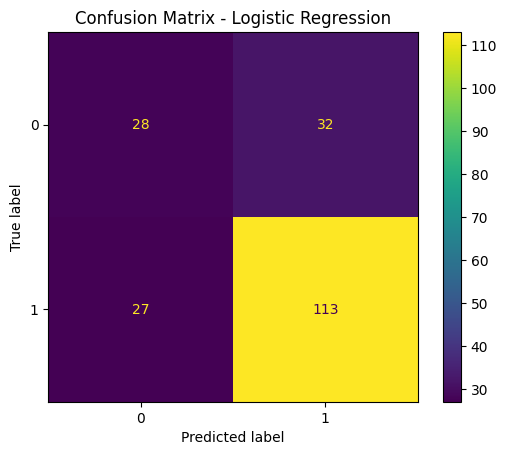

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(baseline_model, X_test, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### 10. Train Sequential Ensemble Model (AdaBoostClassifier)

In [102]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)

adaboost_model.fit(X_train, y_train)

print("AdaBoost model trained successfully.")

AdaBoost model trained successfully.


### 10.1 Evaluate AdaBoost Model Performance

In [103]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

y_pred_adaboost = adaboost_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_adaboost))
print("Precision:", precision_score(y_test, y_pred_adaboost))
print("Recall:", recall_score(y_test, y_pred_adaboost))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_adaboost))

Accuracy: 0.715
Precision: 0.7712418300653595
Recall: 0.8428571428571429

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.42      0.47        60
           1       0.77      0.84      0.81       140

    accuracy                           0.71       200
   macro avg       0.65      0.63      0.64       200
weighted avg       0.70      0.71      0.70       200



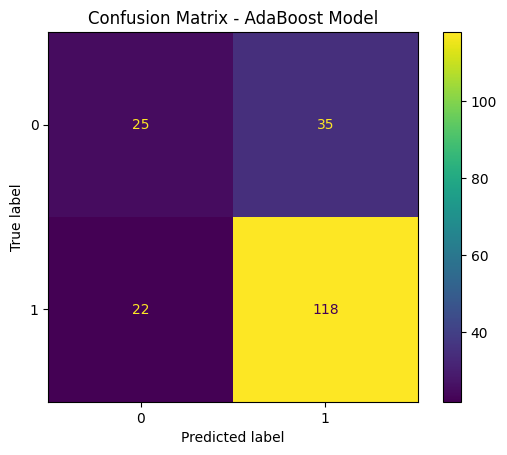

In [104]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(adaboost_model, X_test, y_test)
plt.title("Confusion Matrix - AdaBoost Model")
plt.show()

## Explain why this method / choice of hyperparameters is suitable for the given dataset.
In this project, the **AdaBoost classifier** was used as a **sequential ensemble learning method** to improve prediction performance for the credit approval dataset. Since the dataset represents a **binary classification** problem (good and bad credit risk) with multiple categorical and numerical features, AdaBoost is a suitable choice because it combines several weak learners sequentially and focuses more on previously misclassified samples during training.

The parameters **n_estimators = 100** and **learning_rate = 0.5** were selected to balance model complexity and stability. Using 100 estimators allows the model to learn patterns step by step from the training data, while the learning rate controls how strongly each weak learner contributes to the final prediction. These values provided stable performance without increasing the risk of overfitting.

After training, the AdaBoost model achieved an **accuracy of 71.5 %**, with a **recall score of 84.3%**, showing that the model was effective in correctly identifying most of the creditworthy applicants. This makes the model suitable for credit approval prediction tasks where identifying reliable applicants is important for decision-making.

### 11. Model Comparison Table

In [105]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "AdaBoost"],
    "Accuracy": [0.705, 0.715],
    "Precision": [0.775, 0.771],
    "Recall": [0.814, 0.843]
})

comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.705,0.775,0.814
1,AdaBoost,0.715,0.771,0.843


## Comparison ensemble methods with a baseline model.
The **Logistic Regression** model achieved an accuracy of **70.5%**, while the **AdaBoost model** improved the accuracy slightly to **71.5%**. Although both models produced similar precision values (0.775 for Logistic Regression and 0.771 for AdaBoost), the **AdaBoost** classifier showed **better** recall (0.843) compared to Logistic Regression (0.814).

### 12. Hyperparameter Tuning for AdaBoost (Using GridSearchCV)

In [106]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.5, 1]}

grid_search = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 1, 'n_estimators': 200}


### 13. Train Tuned AdaBoost Model

In [107]:
best_adaboost = grid_search.best_estimator_

y_pred_tuned = best_adaboost.predict(X_test)

### 13.1 Evaluate Tuned Model Performance

In [108]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned Precision:", precision_score(y_test, y_pred_tuned))
print("Tuned Recall:", recall_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.675
Tuned Precision: 0.7659574468085106
Tuned Recall: 0.7714285714285715


### 13.2 Plot Confusion Matrix (Tuned Model)

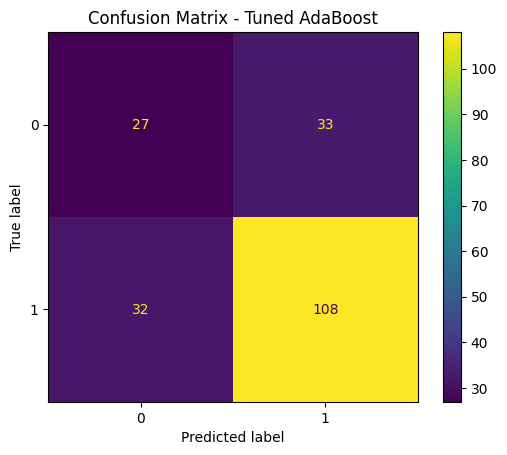

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_adaboost, X_test, y_test)
plt.title("Confusion Matrix - Tuned AdaBoost")
plt.show()

After performing hyperparameter tuning using GridSearchCV, the AdaBoost classifier was retrained with the best parameter values **(n_estimators = 200 and learning_rate = 1)** and evaluated on the test dataset. The **tuned model achieved an accuracy of 67.5%, precision of 0.766, and recall of 0.771**.

The **confusion matrix** shows that the tuned model correctly identified **108** creditworthy applicants and **27** risky applicants, while misclassifying some cases in both categories. Compared to the default AdaBoost model, the tuned version slightly reduced overall accuracy but maintained balanced precision and recall values.

### 13.3 Plot learning curves for AdaBoost

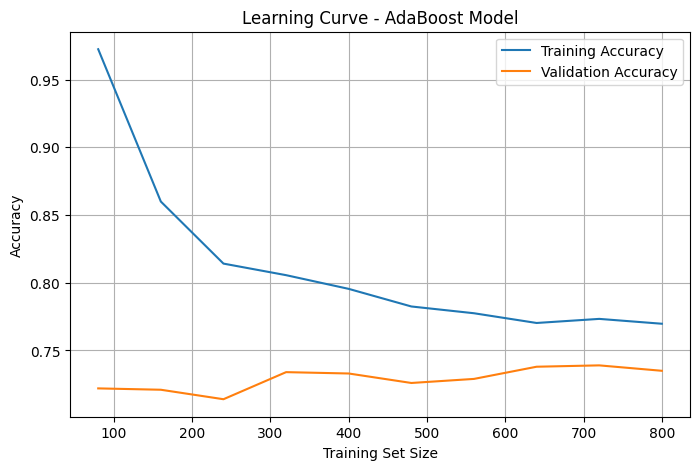

In [110]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    adaboost_model,
    X_encoded,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculate mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot learning curve
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")

plt.title("Learning Curve - AdaBoost Model")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The plot shows that training accuracy starts high and gradually decreases as the dataset size increases, while validation accuracy improves and stabilizes over time.

The gap between training and validation accuracy becomes smaller as more training data is used, which indicates that the model generalizes well and does not suffer from significant overfitting.

### 14. Feature Importance Visualization (AdaBoost)

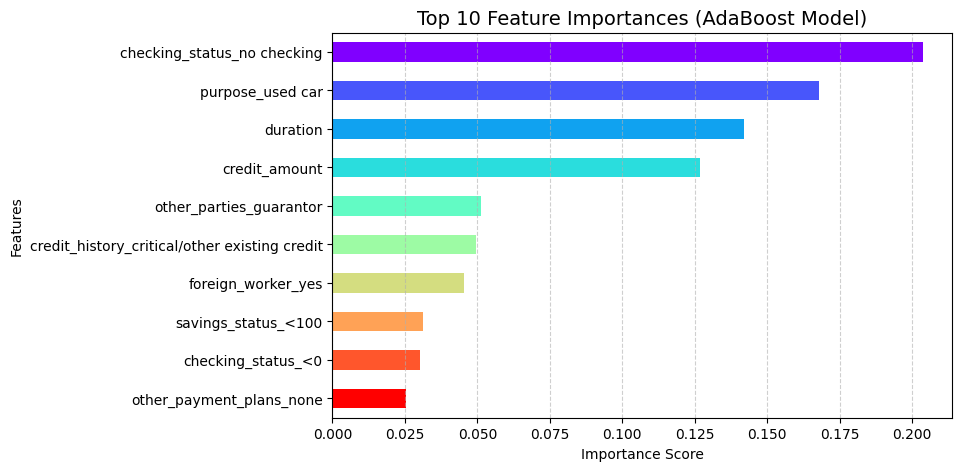

In [111]:
plt.figure(figsize=(8,5))

# Rainbow gradient colors
colors = plt.cm.rainbow(np.linspace(0, 1, len(top_features)))

top_features.plot(
    kind='barh',
    color=colors
)

plt.title("Top 10 Feature Importances (AdaBoost Model)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

The results show that checking account status (no checking account) had the highest importance score, followed by loan purpose (used car), loan duration, and credit amount. These variables play a significant role in determining whether an applicant is classified as a good or bad credit risk.

Other important features included presence of a guarantor, credit history status, foreign worker status, and savings balance below 100, which also contributed to the prediction process. These factors are commonly used in financial risk assessment and help the model evaluate the reliability of loan applicants.

### 15. Ethical Considerations

### 1. What is the source of your dataset (synthetic or UCI ML), and what ethical?
The dataset used in this project is the **Credit Approval** dataset obtained from OpenML through the **scikit-learn** library, which is a publicly available dataset commonly used for studying credit risk prediction.It represents real-world style financial information in anonymized form. Since the dataset relates to loan approval decisions, ethical considerations include ensuring privacy, avoiding misuse of personal financial indicators, and using the model only as a decision-support tool rather than making fully automated approval decisions without human review.

### 2. What potential biases exist in your data or model, and which groups could be affected?
The dataset includes several socio-economic features such as **employment status**, **savings level**, **checking account status**, and **foreign worker** status, which may introduce bias in the model’s predictions. These variables can indirectly reflect differences between groups of applicants and may influence loan approval outcomes unfairly if historical decisions in the data were biased. As a result, certain groups such as **applicants with lower income stability, limited savings, or foreign worker** status could be affected more by the model’s decisions. Therefore, the model should be used carefully with human supervision to ensure fair decision-making.

### 3. What are the real-world consequences of incorrect predictions (false positives/negatives)?
If the model makes a **false positive** prediction, it means a risky applicant is **incorrectly** approved for a loan. In real situations, this could lead to financial loss for the bank if the applicant is unable to repay the loan.
If the model makes a **false negative** prediction, it means a **reliable** applicant is wrongly rejected. This can result in loss of business for the bank and may also be unfair to the customer who actually deserves approval.

So, both types of errors are important and show why such models should support decision-making rather than replace human judgment completely.

### 4. How explainable is your model, and how would you justify its decisions to stakeholders?
The **AdaBoost** model used in this project is reasonably explainable because it provides feature importance scores that show which factors influenced the prediction the most. 
For example, variables like checking account status, loan duration, credit amount, and savings status were identified as important in deciding whether a loan application should be approved or rejected.

These results can be explained to stakeholders by showing which applicant characteristics had the strongest impact on the model’s decisions. This helps managers and analysts understand the reasoning behind predictions and increases confidence in using the model as a support tool for credit approval decisions.

### 5. How could this model be misused, and what safeguards would you suggest?
This model could be misused if it is used as a fully automatic system to approve or reject loan applications without human review. Since the model is trained on historical financial data, it may reflect existing biases and could affect some applicants unfairly. Also, relying only on model predictions may ignore important personal or situational factors that are not included in the dataset.

However, the purpose of building such a model is to support decision-making, not replace human judgment. The model can help banks quickly identify risky and reliable applicants and improve consistency in the screening process. To ensure responsible use, the model should be used together with **human review**, **regular performance** monitoring, and **fairness** checks before making final approval decisions.

### 16. Conclusion
In this project, the **Credit Approval** dataset was used to predict whether a loan applicant is classified as a **good or bad** credit risk using machine learning methods. A baseline **Logistic Regression** model was first applied, and its performance was compared with the **AdaBoost sequential ensemble** model. The AdaBoost classifier showed slightly **better** accuracy and higher recall, which means it was more effective in identifying creditworthy applicants.

Hyperparameter tuning was performed using **GridSearchCV**, but the default AdaBoost model provided better overall performance on the test data. The learning curve indicated that the model generalized well without major overfitting. Feature importance analysis showed that **checking account status, loan purpose, loan duration, and credit amount** were the most influential factors in credit approval decisions.

Overall, the AdaBoost model proved to be a suitable method for this classification task and helped improve prediction performance compared to the baseline model.